In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import numpy as np

### Helping Functions

In [14]:
def load_img(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return np.asarray(Image.open(path))


def show_img(ax, img, title=None, panel_label=None):
    ax.imshow(img)
    ax.axis("off")

    if title is not None:
        ax.set_title(title, fontsize=11, pad=4)

    if panel_label is not None:
        ax.text(
            0.01, 0.99,
            panel_label,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=13,
            fontweight="bold",
            color="black",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=2)
        )
        
        
def add_img_ax(fig, img, rect, title=None, panel_label=None):
    """
    rect = [left, bottom, width, height] in figure coordinates.
    """
    ax = fig.add_axes(rect)
    ax.imshow(img)
    ax.axis("off")

    if title is not None:
        ax.set_title(title, fontsize=12, pad=3)

    if panel_label is not None:
        ax.text(
            -0.025, 1.02,
            panel_label,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=14,
            fontweight="bold",
            color="black"
        )

    return ax


def show_panel(fig, img, rect, title=None, panel_label=None):
    ax = fig.add_axes(rect)
    ax.imshow(img)
    ax.axis("off")

    if title is not None:
        ax.set_title(title, fontsize=11, pad=3)

    if panel_label is not None:
        ax.text(
            -0.035, 1.02,
            panel_label,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=14,
            fontweight="bold",
            color="black"
        )

    return ax


def crop_from_bottom_left_to_ratio(img, target_ratio):
    """
    Crop image to target width/height ratio, anchored at bottom-left.
    Keeps the axis icon / labels in the lower-left corner.
    """
    h, w = img.shape[:2]
    current_ratio = w / h

    if current_ratio > target_ratio:
        # image too wide -> crop width, keep left side
        new_w = int(round(h * target_ratio))
        return img[:, :new_w]
    else:
        # image too tall -> crop height, keep bottom
        new_h = int(round(w / target_ratio))
        return img[h - new_h:, :]

In [11]:
base_dir = Path("../../figures/subexp01/individual")
fourier_dir = Path("../../figures/subexp01/fourier_panels")  # falls du so einen Ordner hast

condition = "70_vs_50"

paths = {
    "XY": base_dir / "subexp01_abs_overlay_XY_70_vs_50_natural_aspect.png",
    "XZ": base_dir / "subexp01_abs_overlay_XZ_70_vs_50_natural_aspect.png",
    "YZ": base_dir / "subexp01_abs_overlay_YZ_70_vs_50_natural_aspect.png",

    # anpassen an deinen echten Fourier-Dateinamen
    "Fourier": fourier_dir / "subexp01_fourier_abs_logpower_XZ_70_vs_50.png",
}

### Loading Images

In [12]:
imgs = {key: load_img(path) for key, path in paths.items()}

### PLOT

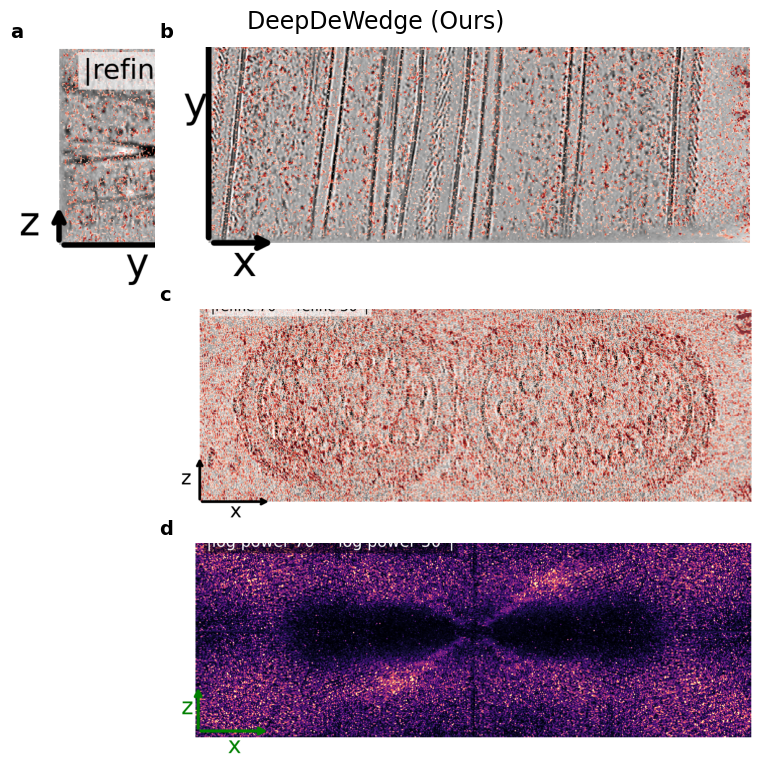

Saved: ..\..\figures\final_report\final_subexp01_70_vs_50_squarelayout.png
Saved: ..\..\figures\final_report\final_subexp01_70_vs_50_squarelayout.pdf


In [15]:
plt.close("all")

fig = plt.figure(figsize=(8.2, 8.2))
fig.suptitle("DeepDeWedge (Ours)", fontsize=17, y=0.975)

# ------------------------------------------------------------
# square-style layout like the paper
# ------------------------------------------------------------

left_margin = 0.06
right_margin = 0.04
bottom_margin = 0.06
top_margin = 0.07

col_gap = 0.03
row_gap = 0.025

# right block = XY / XZ / Fourier column
main_left = 0.26
main_w = 1.0 - right_margin - main_left

# bottom two panels: XZ and Fourier have SAME width
xz_h = main_w * (imgs["XZ"].shape[0] / imgs["XZ"].shape[1])
ft_h = main_w * (imgs["Fourier"].shape[0] / imgs["Fourier"].shape[1])

# small shrink factors if needed
xz_h *= 0.92
ft_h *= 0.92

rect_ft = [main_left, bottom_margin, main_w, ft_h]
rect_xz = [main_left, bottom_margin + ft_h + row_gap, main_w, xz_h]

# top row fills remaining height
top_bottom = rect_xz[1] + rect_xz[3] + row_gap
top_h = 1.0 - top_margin - top_bottom

# left panel width comes from remaining horizontal space
yz_w = main_left - left_margin - col_gap

rect_yz = [left_margin, top_bottom, yz_w, top_h]
rect_xy = [main_left,   top_bottom, main_w, top_h]

# ------------------------------------------------------------
# crop each imported PNG so it fits its box
# IMPORTANT: crop from bottom-left to preserve axis icon
# ------------------------------------------------------------

img_yz = crop_from_bottom_left_to_ratio(imgs["YZ"], rect_yz[2] / rect_yz[3])
img_xy = crop_from_bottom_left_to_ratio(imgs["XY"], rect_xy[2] / rect_xy[3])
img_xz = crop_from_bottom_left_to_ratio(imgs["XZ"], rect_xz[2] / rect_xz[3])
img_ft = crop_from_bottom_left_to_ratio(imgs["Fourier"], rect_ft[2] / rect_ft[3])

# ------------------------------------------------------------
# draw panels
# ------------------------------------------------------------

show_panel(fig, img_yz, rect_yz, panel_label="a")
show_panel(fig, img_xy, rect_xy, panel_label="b")
show_panel(fig, img_xz, rect_xz, panel_label="c")
show_panel(fig, img_ft, rect_ft, panel_label="d")

save_png = out_dir / "final_subexp01_70_vs_50_squarelayout.png"
save_pdf = out_dir / "final_subexp01_70_vs_50_squarelayout.pdf"

plt.savefig(save_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.savefig(save_pdf, bbox_inches="tight", pad_inches=0.02)
plt.show()

print("Saved:", save_png)
print("Saved:", save_pdf)